In [1]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt

from itertools import product
import os
import h5py
from tqdm import tqdm

#few utils
from few.utils.utility import get_p_at_t
from few.utils.constants import MTSUN_SI
from few.utils.geodesic import get_fundamental_frequencies
#few trajectory
from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode.flux import SuperKludgeFlux
#few waveform
from few.waveform import FastKerrEccentricEquatorialFlux, GenerateEMRIWaveform
from few.waveform.waveform import SuperKludgeWaveform
from few.utils.constants import YRSID_SI

#sef imports
from stableemrifisher.fisher import StableEMRIFisher
from stableemrifisher.utils import generate_PSD, padding, inner_product
from stableemrifisher.fisher.derivatives import derivative
from stableemrifisher.noise import sensitivity_LWA

#lisa-on-gpu import
from fastlisaresponse import ResponseWrapper  # Response function 

#LISAanalysistools imports
from lisatools.detector import ESAOrbits, EqualArmlengthOrbits #ESAOrbits correspond to esa-trailing-orbits.h5, EqualArmlengthOrbits are equalarmlength-orbits.h5
from lisatools.sensitivity import get_sensitivity, A1TDISens, E1TDISens, T1TDISens

use_gpu = True #False if your computer sucks (mine does)

if not use_gpu:
    
    import few
    
    #tune few configuration
    cfg_set = few.get_config_setter(reset=True)
    
    cfg_set.enable_backends("cpu")
    cfg_set.set_log_level("info");
else:
    pass #let the backend decide for itself.

startup


In [2]:
#fixed parameters
T_LISA = 2.0 #observation time, years. !!!should be 2 years in the full run!!!
dt = 10.0 #sampling interval, seconds

m1 = 1e6 #MBH mass in solar masses (source frame)
m2 = 10.0 #secondary mass in solar masses (source frame)
x0 = 1.0 #inclination, must be = 1.0 for equatorial model
p0_buffer = 0.5 #while p0 will be determined by T_LISA assuming a plunging EMRI, the StableEMRIFisher code may not be suitable for plunge cases. We thus introduce this small buffer to extend the inspiral.

# initial phases
Phi_phi0 = 0.1 #azimuthal phase
Phi_theta0 = 0.2 #polar phase
Phi_r0 = 0.3 #radial phase

# define the extrinsic parameters
qS = np.pi/3
phiS = np.pi/4
qK = np.pi/5.
phiK = np.pi/6.
dist = 1.0  # distance in Gpc. We'll adjust this later to fix the SNR as SNR_threshold
SNR_threshold = 20.0

filename = f'CVbiases_Mtot_{m1+m2}'
if not os.path.exists(filename):
    os.mkdir(filename)

#initializing trajectories
SK_traj = EMRIInspiral(func=SuperKludgeFlux)

chi2 = 0.5
evolve_1PA = True
evolve_primary = False
evolve_2PA = True
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA] #args for the "true" 2PA waveform

In [3]:
#grid parameters (p and e for now)
N = 3

try:
    with h5py.File(f"{filename}/data.h5", "r") as f:
        param_grid = f["gridpoints"][:]  # Read the dataset into a NumPy array
        p_range = f["p0"][:] + p0_buffer #buffer
    try:
        with h5py.File(f"{filename}/data.h5", "r") as f:
            dist_range = f["dists"][:]  # Read the dataset into a NumPy array
    except KeyError:
        pass #will be handled later
        
except FileNotFoundError:
    
    a_range = np.linspace(0.1,0.9,N)
    e_range = np.linspace(0.1,0.5,N) #eccentricity above 0.5 is extremely expensive already...
    
    # Generate the Cartesian product of all parameter values
    param_grid = np.array(list((product(a_range, e_range))))
    
    p_range = []
    for i in tqdm(range(len(param_grid))):
        a = param_grid[i,0]
        e0 = param_grid[i,1]
        
        p0 = get_p_at_t(traj_module=SK_traj, t_out=T_LISA, traj_args=[m1, m2, a, e0, x0, *add_args])
        
        p_range.append(p0)

        #check p for plunge trajectories
        #t, p, e, x, pp, pt, pr = kerr_traj(m1, m2, a, p0, e0, x0, Phi_phi0=Phi_phi0, Phi_theta0=Phi_theta0, Phi_r0=Phi_r0, T=T_LISA, dt=dt)
    
        #print(t[-1] - (T_LISA*YRSID_SI))
        
    p_range = np.array(p_range)

    print(param_grid.shape, p_range.shape)
    
    #save as an h5py file
    with h5py.File(f"{filename}/data.h5", "w") as f:
        f.create_dataset("gridpoints", data=param_grid)
        f.create_dataset("p0", data=p_range) #save plunging traj p0
        
    p_range += p0_buffer #buffer
    
    #with h5py.File(f"{filename}/p_e_grid_data.h5", "r") as f:
    #    loaded_data = f["dataset_name"][:]  # Read the dataset into a NumPy array
    
    #print(loaded_data)
    
    plt.scatter(param_grid[:,0],param_grid[:,1])
    plt.xlabel('a range',fontsize=16)
    plt.ylabel('e0 range',fontsize=16)
    plt.savefig(f"{filename}/grid.png",dpi=300,bbox_inches='tight')
    plt.show()

In [4]:
#initialize waveform model
sum_kwargs = {
    "pad_output": True, # True if expecting waveforms smaller than LISA observation window.
}

max_step_days = 10.0 #max trajectory step size in days

inspiral_kwargs = {
    "err":1e-11, #default = 1e-11
    "max_step_size":max_step_days*24*60*60, #in seconds
}

waveform_model = GenerateEMRIWaveform(
            SuperKludgeWaveform,
            sum_kwargs=sum_kwargs,
            inspiral_kwargs=inspiral_kwargs,
            return_list=False,
            )

#setup LISA response
tdi_gen ="2nd generation"# "2nd generation"#

order = 20  # interpolation order (should not change the result too much)
tdi_kwargs_esa = dict(
    orbits=EqualArmlengthOrbits(use_gpu=use_gpu), order=order, tdi=tdi_gen, tdi_chan="AET",
)

index_lambda = 8
index_beta = 7

# with longer signals we care less about this
t0 = 10000.0  # throw away on both ends when our orbital information is weird

waveform_response = ResponseWrapper(
                        waveform_gen=waveform_model,
                        Tobs=T_LISA,
                        t0=t0,
                        dt=dt,
                        index_lambda=index_lambda,
                        index_beta=index_beta,
                        flip_hx=True,  # set to True if waveform is h+ - ihx (FEW is)
                        use_gpu=use_gpu,
                        is_ecliptic_latitude=False,  # False if using polar angle (theta)
                        remove_garbage="zero",  # removes the beginning of the signal that has bad information
                        **tdi_kwargs_esa,
                        )

In [5]:
#calculate and save SNR-adjusted dist

#calculate Fishers at each grid point
channels = [A1TDISens, E1TDISens, T1TDISens]
noise_kwargs = [{"sens_fn": channel_i} for channel_i in channels]

param_names = ['M','mu','a','chi2','p0','e0','dist','qS','phiS','qK','phiK','Phi_phi0','Phi_r0'] #M, mu are primary and secondary masses in the SEF code respectively. This will be made consistent with FEW in a later version.

add_param_args = {'chi2':chi2,
                  '1PA':evolve_1PA,
                  'evolve_primary':evolve_primary,
                  '2PA':evolve_2PA} #dict of parameters NOT included by default in SEF. This contains the additional SK parameters. 

sef_kwargs = {'EMRI_waveform_gen':waveform_response, #EMRI waveform model with TDI response.
              'param_names': param_names, #params to be varied
              'der_order':2, #derivative order. Available options: 2, 4, 6, 8
              'Ndelta':8, #number of stable points, can be any integer.
              'stats_for_nerds': False, #true if you wanna print debugging info
              'stability_plot': False, #true if you wanna plot stability surfaces
              'use_gpu':use_gpu,
              'filename': filename, #filename where Fishers to be stored
              'noise_model':get_sensitivity,
              'channels':channels,
              'noise_kwargs':noise_kwargs,
              'add_param_args':add_param_args,
              'plunge_check':False, #save time by avoiding internal check for plunging trajectories (this is ensured by our choice of p0)
             }

emri_kwargs = {'T': T_LISA, 'dt': dt}

try:
    with h5py.File(f"{filename}/data.h5", "r") as f:
        dist_range = f["dists"][:]  # Read the dataset into a NumPy array

except:
    
    dist_range = []
    for i in tqdm(range(len(param_grid))):
        a = param_grid[i][0]
        e0 = param_grid[i][1]
        p0 = p_range[i]
    
        param_list = [m1, m2, a, p0, e0, x0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
                
        #calculate Fisher
        sef = StableEMRIFisher(*param_list, **emri_kwargs, **sef_kwargs)
        SNR_before = sef.SNRcalc_SEF()
        dist_fact = SNR_before/SNR_threshold #adjust distance such that SNR = SNR_threshold
        
        param_list[6] *= dist_fact
        dist_range.append(dist*dist_fact)
    
        del sef
    
        sef = StableEMRIFisher(*param_list, **emri_kwargs, **sef_kwargs)
        SNR_after = sef.SNRcalc_SEF()
    
        print("SNR before: ", SNR_before, "SNR_after: ", SNR_after)
    
    #save as an h5py file
    with h5py.File(f"{filename}/data.h5", "a") as f:
        f.create_dataset("dists", data=np.array(dist_range))

  0%|                                                                                                                                                          | 0/9 [00:00<?, ?it/s]

wave ndim:  2
Computing SNR for parameters: {'m1': 1000000.0, 'm2': 10.0, 'a': np.float64(0.1), 'p0': np.float64(10.880182320198315), 'e0': np.float64(0.1), 'Y0': 1.0, 'dist': 1.0, 'qS': 1.0471975511965976, 'phiS': 0.7853981633974483, 'qK': 0.6283185307179586, 'phiK': 0.5235987755982988, 'Phi_phi0': 0.1, 'Phi_theta0': 0.2, 'Phi_r0': 0.3, 'chi2': 0.5, '1PA': True, 'evolve_primary': False, '2PA': True}
wave ndim:  2
Computing SNR for parameters: {'m1': 1000000.0, 'm2': 10.0, 'a': np.float64(0.1), 'p0': np.float64(10.880182320198315), 'e0': np.float64(0.1), 'Y0': 1.0, 'dist': np.float64(1.7161606392661344), 'qS': 1.0471975511965976, 'phiS': 0.7853981633974483, 'qK': 0.6283185307179586, 'phiK': 0.5235987755982988, 'Phi_phi0': 0.1, 'Phi_theta0': 0.2, 'Phi_r0': 0.3, 'chi2': 0.5, '1PA': True, 'evolve_primary': False, '2PA': True}


 11%|████████████████▏                                                                                                                                 | 1/9 [00:18<02:27, 18.41s/it]

SNR before:  34.32321278532269 SNR_after:  19.99999999999994
wave ndim:  2
Computing SNR for parameters: {'m1': 1000000.0, 'm2': 10.0, 'a': np.float64(0.1), 'p0': np.float64(10.887781902371465), 'e0': np.float64(0.30000000000000004), 'Y0': 1.0, 'dist': 1.0, 'qS': 1.0471975511965976, 'phiS': 0.7853981633974483, 'qK': 0.6283185307179586, 'phiK': 0.5235987755982988, 'Phi_phi0': 0.1, 'Phi_theta0': 0.2, 'Phi_r0': 0.3, 'chi2': 0.5, '1PA': True, 'evolve_primary': False, '2PA': True}
wave ndim:  2
Computing SNR for parameters: {'m1': 1000000.0, 'm2': 10.0, 'a': np.float64(0.1), 'p0': np.float64(10.887781902371465), 'e0': np.float64(0.30000000000000004), 'Y0': 1.0, 'dist': np.float64(2.25194361430781), 'qS': 1.0471975511965976, 'phiS': 0.7853981633974483, 'qK': 0.6283185307179586, 'phiK': 0.5235987755982988, 'Phi_phi0': 0.1, 'Phi_theta0': 0.2, 'Phi_r0': 0.3, 'chi2': 0.5, '1PA': True, 'evolve_primary': False, '2PA': True}


 22%|████████████████████████████████▍                                                                                                                 | 2/9 [00:23<01:13, 10.46s/it]

...

SNR before:  88.94266609467765 SNR_after:  20.000000000000004
wave ndim:  2
Computing SNR for parameters: {'m1': 1000000.0, 'm2': 10.0, 'a': np.float64(0.9), 'p0': np.float64(9.016936844567027), 'e0': np.float64(0.30000000000000004), 'Y0': 1.0, 'dist': 1.0, 'qS': 1.0471975511965976, 'phiS': 0.7853981633974483, 'qK': 0.6283185307179586, 'phiK': 0.5235987755982988, 'Phi_phi0': 0.1, 'Phi_theta0': 0.2, 'Phi_r0': 0.3, 'chi2': 0.5, '1PA': True, 'evolve_primary': False, '2PA': True}
wave ndim:  2
Computing SNR for parameters: {'m1': 1000000.0, 'm2': 10.0, 'a': np.float64(0.9), 'p0': np.float64(9.016936844567027), 'e0': np.float64(0.30000000000000004), 'Y0': 1.0, 'dist': np.float64(4.944039981626603), 'qS': 1.0471975511965976, 'phiS': 0.7853981633974483, 'qK': 0.6283185307179586, 'phiK': 0.5235987755982988, 'Phi_phi0': 0.1, 'Phi_theta0': 0.2, 'Phi_r0': 0.3, 'chi2': 0.5, '1PA': True, 'evolve_primary': False, '2PA': True}


 89%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊                | 8/9 [00:52<00:05,  5.14s/it]

SNR before:  98.88079963253206 SNR_after:  20.00000000000003
wave ndim:  2
Computing SNR for parameters: {'m1': 1000000.0, 'm2': 10.0, 'a': np.float64(0.9), 'p0': np.float64(8.905460616527924), 'e0': np.float64(0.5), 'Y0': 1.0, 'dist': 1.0, 'qS': 1.0471975511965976, 'phiS': 0.7853981633974483, 'qK': 0.6283185307179586, 'phiK': 0.5235987755982988, 'Phi_phi0': 0.1, 'Phi_theta0': 0.2, 'Phi_r0': 0.3, 'chi2': 0.5, '1PA': True, 'evolve_primary': False, '2PA': True}
wave ndim:  2
Computing SNR for parameters: {'m1': 1000000.0, 'm2': 10.0, 'a': np.float64(0.9), 'p0': np.float64(8.905460616527924), 'e0': np.float64(0.5), 'Y0': 1.0, 'dist': np.float64(5.667075904299805), 'qS': 1.0471975511965976, 'phiS': 0.7853981633974483, 'qK': 0.6283185307179586, 'phiK': 0.5235987755982988, 'Phi_phi0': 0.1, 'Phi_theta0': 0.2, 'Phi_r0': 0.3, 'chi2': 0.5, '1PA': True, 'evolve_primary': False, '2PA': True}


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:57<00:00,  6.40s/it]

SNR before:  113.3415180859961 SNR_after:  19.99999999999997


In [6]:
def logmasstransform(Fisher, m1, m2, index_of_m1 = 0, index_of_m2 = 1):
    """ transform m1, m2 -> lnm1, lnm2. Fisher transformation: https://en.wikipedia.org/wiki/Fisher_information """
    
    J = np.eye(len(Fisher))
    J[index_of_m1,index_of_m1] = m1
    J[index_of_m2,index_of_m2] = m2
    
    return J.T@Fisher@J


In [7]:
def cutlervallis(waveform_truth, waveform_approx, Fisher_truth, partial_approx, params_truth, PSD_func, dt, use_gpu=False):
    """
    Calculate best-fit param points using the Cutler-Vallisneri linear-bias approximation.
    
    params:
    
        waveform_truth (ndarray) : the time-series waveform from the true template at params_truth. ndarray of shape 'N x M' where N is number of LISA channels and M is the time-series length
        waveform_approx (ndarray) : the time-series waveform from the approximate template at params_truth. ndarray of shape 'N x M' where N is number of LISA channels and M is the time-series length
        partial_approx (ndarray) : the time-series partial derivative of the approximate template at params_truth. ndarray of shape 'N x M' where N is number of LISA channels and M is the time-series length
        Fisher_truth (ndarray) : the Fisher matrix (log-mass units) at params_truth. ndarray of shape 'd x d'
        params_truth (ndarray) : the array of true params. ndarray of shape 'd'
        PSD_func (ndarray) : the frequency-domain LISA noise sensitivity curve. ndarray of shape 'N x L' where L is the length of the frequency series. 

    returns:
    
        CV_bias (ndarray): params_truth + np.linalg.inv(Fisher_truth) @ inner_product(partial_approx, waveform_truth - waveform_approx)
    """

    if use_gpu:
        xp = cp
    else:
        xp = np
        
    waveform_truth = padding(waveform_truth, waveform_approx, use_gpu = use_gpu) #make waveform_truth the same length as waveform_approx

    delta_wave = waveform_truth - waveform_approx
    
    # calculate all the column-wise inner products
    
    inn_prods = []
    
    for j in range(len(Fisher_truth)):
        
        print("delta_wave.shape, partial_approx.shape: ", delta_wave.shape, partial_approx[j].shape)
                      
        inn_prod_j = inner_product(partial_approx[j], delta_wave, PSD=PSD_func, dt=dt, use_gpu = use_gpu) #should be a scalar

        inn_prod_j = xp.asarray(inn_prod_j)
        
        print(f'inner_prod at j = {j}: ', inn_prod_j)
        
        if use_gpu:
            inn_prod_j = xp.asnumpy(inn_prod_j)
        
        inn_prods.append(inn_prod_j)
        
    inn_prods = np.array(inn_prods)
        
    # calculate all the param shifts
    
    delta_param_all = []
    
    for i in range(len(Fisher_truth)):
            
        delta_param_i = np.linalg.inv(Fisher_truth)[i,:]@inn_prods

        delta_param_all.append(delta_param_i)
        
    print('delta_param_all: ', delta_param_all)
        
    return params_truth + np.array(delta_param_all)

In [ ]:
#initialize the 1PA (approximate) model

evolve_1PA = True
evolve_primary = False
evolve_2PA = False
add_args_alt = [chi2, evolve_1PA, evolve_primary, evolve_2PA]

filename_bias = os.path.join(filename,"1PA") #this is where the 1PA approximate Fishers will be stored.

param_names = ['m1','m2','a','chi2','p0','e0','dist','qS','phiS','qK','phiK','Phi_phi0','Phi_r0']

add_param_args = {'chi2':chi2,
              '1PA':evolve_1PA,
              'evolve_primary':evolve_primary,
              '2PA':evolve_2PA} #dict of parameters NOT included by default in SEF. This contains the additional SK parameters. 

#update sef_kwargs
sef_kwargs = {'EMRI_waveform_gen':waveform_response, #EMRI waveform model with TDI response
          'param_names': param_names, #params to be varied
          'der_order':2, #derivative order
          'Ndelta':8, #number of stable points
          'stats_for_nerds': False, #true if you wanna print debugging info
          'stability_plot': False, #true if you wanna plot stability surfaces
          'use_gpu':use_gpu,
          'filename': filename_bias,
          'noise_model':get_sensitivity,
          'channels':channels,
          'noise_kwargs':noise_kwargs,
          'add_param_args':add_param_args,
          'plunge_check':False, #save time by avoiding internal check for plunging trajectories (this is ensured by our choice of p0)
          }
    
for i in tqdm(range(len(param_grid))):

    print(f"Calculating Fishers for 1PA waveforms")
    
    try:
        #skip Fishers which are already calculated.
        with h5py.File(f"{filename_bias}/Fisher_{i}.h5", "r") as f:
            _ = f["Fisher"][:]
        continue

    except FileNotFoundError:
        a = param_grid[i][0]
        e0 = param_grid[i][1]
        p0 = p_range[i]
        dist = dist_range[i]

        sef_kwargs['suffix'] = i

        param_list = [m1, m2, a, p0, e0, x0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]

        #calculate Fisher
        sef = StableEMRIFisher(*param_list, **emri_kwargs, **sef_kwargs)
        sef()

print("Transforming to log-mass")

for i in range(len(param_grid)):

    try:
        with h5py.File(f"{filename_bias}/Fisher_{i}.h5", "r") as f:
            _ = f["Fisher_transformed"][:]
        continue
    except KeyError:
        with h5py.File(f"{filename_bias}/Fisher_{i}.h5", "r") as f:
            Fisher = f["Fisher"][:]
        Fisher_transform = logmasstransform(Fisher, m1, m2)
        with h5py.File(f"{filename_bias}/Fisher_{i}.h5", "a") as f: #'a' mode for appending existing datasets.
            f.create_dataset("Fisher_transformed", data=Fisher_transform)

print("Checking log-mass Fisher positive-definiteness...")

check_flag = True

for i in tqdm(range(len(param_grid))):

    with h5py.File(f"{filename_bias}/Fisher_{i}.h5", "r") as f:
        Fisher = f["Fisher"][:]

    with h5py.File(f"{filename_bias}/Fisher_{i}.h5", "r") as f:
        Fisher_transformed = f["Fisher_transformed"][:]

    #if you want to exclude sus parameters for troubleshooting
    rows_to_remove = []
    for j in range(len(param_names)):
        if param_names[j] in []:#'dist','qS','phiS','qK','phiK','Phi_phi0','Phi_r0']:
            rows_to_remove.append(j)

    rows_to_remove = np.array(rows_to_remove)
    
    if len(rows_to_remove) > 0:
        Fisher_transformed = np.delete(np.delete(Fisher_transformed,rows_to_remove,axis=0),rows_to_remove,axis=1)
        Fisher = np.delete(np.delete(Fisher,rows_to_remove,axis=0),rows_to_remove,axis=1)

    if (np.linalg.eigvals(Fisher_transformed) < 0.0).any():
        check_flag = False
        print('positive definiteness failed for: ', i)
        
if check_flag:
    print("positive-definiteness check passed!")

print(f"Calculating Cutler-Vallisneri Biases")

removed_params = []

for i in tqdm(range(len(param_grid))):

    sef_kwargs['suffix'] = i
        
    print(f"Calculating derivatives")

    try:
        #do not calculate derivatives that have already been calculated.
        with h5py.File(f"{filename_bias}/derivatives_{i}.h5", "r") as f:
            _ = f["derivatives"][:]
        continue

    except FileNotFoundError:
        a = param_grid[i][0]
        e0 = param_grid[i][1]
        p0 = p_range[i]
        dist = dist_range[i]
    
        param_list = [m1, m2, a, p0, e0, x0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
    
        sef = StableEMRIFisher(*param_list, **emri_kwargs, **sef_kwargs)
        rho = sef.SNRcalc_SEF()
        sef.SNR2 = rho**2
        print(f'Waveform Generated. SNR: {rho}')

        if sef.filename != None:
            if not os.path.exists(sef.filename):
                os.makedirs(sef.filename)
            
        print(f'calculating derivatives at {param_list}...')

        #use the same deltas as used for the Fisher calculation in the previous part for the 1PA model

        with open(f"{filename_bias}/stable_deltas_{i}.txt", "r") as file:
            data = file.read()
            deltas = eval(data)
        
        sef.deltas = deltas

        Fisher = np.zeros((sef.npar,sef.npar), dtype=np.float64)
        dtv = []
        for k in range(sef.npar):
        
            if sef.param_names[k] in list(sef.minmax.keys()):
                if sef.wave_params[sef.param_names[k]] <= sef.minmax[sef.param_names[k]][0]:
                    dtv.append(derivative(sef.waveform_generator, sef.wave_params, sef.param_names[k], sef.deltas[sef.param_names[k]], kind="forward", waveform=sef.waveform, order=sef.order, use_gpu=sef.use_gpu, waveform_kwargs=sef.waveform_kwargs))
                elif sef.wave_params[sef.param_names[k]] > sef.minmax[sef.param_names[k]][1]:
                    dtv.append(derivative(sef.waveform_generator, sef.wave_params, sef.param_names[k],sef.deltas[sef.param_names[k]], kind="backward", waveform=sef.waveform, order=sef.order, use_gpu=sef.use_gpu, waveform_kwargs=sef.waveform_kwargs))
                else:
                    dtv.append(derivative(sef.waveform_generator, sef.wave_params, sef.param_names[k],sef.deltas[sef.param_names[k]],use_gpu=sef.use_gpu, waveform=sef.waveform, order=sef.order, waveform_kwargs=sef.waveform_kwargs))
            else:
                dtv.append(derivative(sef.waveform_generator, sef.wave_params, sef.param_names[k], sef.deltas[sef.param_names[k]],use_gpu=sef.use_gpu, waveform=sef.waveform, order=sef.order, waveform_kwargs=sef.waveform_kwargs))

        print("Finished derivatives")

        if sef.use_gpu:
            dtv = cp.asnumpy(cp.asarray(dtv)) #h5py only stores numpy
            
        #Jacobian transform to log-masses
        for k in range(sef.npar):
            if sef.param_names[k] == 'm1':
                dtv[k] *= m1 #to obtain \partial_{log m1}h
            elif sef.param_names[k] == 'm2':
                dtv[k] *= m2 #to obtain \partial_{log m2}h

    #actually calculating and savin the biases
    a = param_grid[i][0]
    e0 = param_grid[i][1]
    p0 = p_range[i]
    dist = dist_range[i]
    
    params_truth = [m1, m2, a, p0, e0, x0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
    
    params_truth_in = np.array([m1, m2, a, chi2, p0, e0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_r0]) #params from which Fisher is calculated.
    params_truth_in_transformed = np.array([np.log(m1), np.log(m2), a, chi2, p0, e0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_r0]) #params from which the transformed Fisher is calculated.
    
    #import the Fisher matrix
    with h5py.File(f"{filename_bias}/Fisher_{i}.h5", "r") as f:
        Fisher_transformed = f["Fisher_transformed"][:]
    
    print("Calculating Mahalonobis Distance")
    
    sef = StableEMRIFisher(*params_truth, **emri_kwargs, **sef_kwargs)
    rho = sef.SNRcalc_SEF() #generates the PSD and the approximate waveform

    PSD_func = sef.PSD_funcs
    waveform_approx = sef.waveform

    partial_approx = dtv
    
    rows_to_remove = []
    for _ in range(len(param_names)):
        if param_names[_] in removed_params:#'qK','phiK']:
            rows_to_remove.append(_)

    rows_to_remove = np.array(rows_to_remove)

    if len(rows_to_remove) > 0:
        Fisher_transformed = np.delete(np.delete(Fisher_transformed,rows_to_remove,axis=0),rows_to_remove,axis=1)
        partial_approx = np.delete(partial_approx, rows_to_remove, axis=0)
        params_truth_in_transformed = np.delete(params_truth_in_transformed, rows_to_remove, axis=0)
    
    #calculate the waveform using the full template
    waveform_truth = waveform_response(*params_truth, *add_param_args, **emri_kwargs) #2PA waveform

    biased_params = cutlervallis(waveform_truth=waveform_truth, waveform_approx=waveform_approx,
                                 Fisher_truth=Fisher_transformed, partial_approx=partial_approx,
                                 params_truth=params_truth_in_transformed, PSD_func = PSD_func, dt = dt,
                                  use_gpu=use_gpu)

    if use_gpu:
        biased_params = cp.asnumpy(cp.asarray(biased_params))

    #prior box on chi2
    if 'chi2' not in removed_params:
        index_chi2 = np.where(param_names == 'chi2')
        
        if biased_params[index_chi2] > 1.0:
            biased_params[index_chi2] = 1.0
        elif biased_params[index_chi2] < -1.0:
            biased_params[index_chi2] = -1.0

    with h5py.File(f"{filename_bias}/biased_params_{i}.h5", "w") as f:
        f.create_dataset("biased_params", data=biased_params) #saved in log-masses!!!

    print('biased params: ', biased_params)

    #calculate the sigma contour as the Mahalanobis distance between the true and biased params (https://en.wikipedia.org/wiki/Mahalanobis_distance):
    
    sigma_contour = np.sqrt((biased_params - params_truth_in_transformed)@Fisher_transformed@(biased_params - params_truth_in_transformed))
    sigma_contour /= np.sqrt(len(params_truth_in)) #scaled Mahalonobis distance for dimensional generality
    
    print('sigma contours: ', sigma_contour)

    with h5py.File(f"{filename_bias}/biased_params_{i}.h5", "a") as f: #"a" for appending datapoints/
        f.create_dataset("sigma_contours", data=sigma_contour) #in log-masses!!!

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:00<00:00, 198.31it/s]


Calculating Fishers for 1PA waveforms
Calculating Fishers for 1PA waveforms
Calculating Fishers for 1PA waveforms
Calculating Fishers for 1PA waveforms
Calculating Fishers for 1PA waveforms
Calculating Fishers for 1PA waveforms
Calculating Fishers for 1PA waveforms
Calculating Fishers for 1PA waveforms
Calculating Fishers for 1PA waveforms
Transforming to log-mass
Checking log-mass Fisher positive-definiteness...


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:00<00:00, 113.89it/s]


positive-definiteness check passed!
Calculating Cutler-Vallisneri Biases


  0%|                                                                                                                                                          | 0/9 [00:00<?, ?it/s]

Calculating derivatives
wave ndim:  2
Computing SNR for parameters: {'m1': 1000000.0, 'm2': 10.0, 'a': np.float64(0.1), 'p0': np.float64(10.880182320198315), 'e0': np.float64(0.1), 'Y0': 1.0, 'dist': np.float64(1.7161606392661344), 'qS': 1.0471975511965976, 'phiS': 0.7853981633974483, 'qK': 0.6283185307179586, 'phiK': 0.5235987755982988, 'Phi_phi0': 0.1, 'Phi_theta0': 0.2, 'Phi_r0': 0.3, 'chi2': 0.5, '1PA': True, 'evolve_primary': False, '2PA': False}
Waveform Generated. SNR: 19.99999999816506
calculating derivatives at [1000000.0, 10.0, np.float64(0.1), np.float64(10.880182320198315), np.float64(0.1), 1.0, np.float64(1.7161606392661344), 1.0471975511965976, 0.7853981633974483, 0.6283185307179586, 0.5235987755982988, 0.1, 0.2, 0.3]...


# Plot

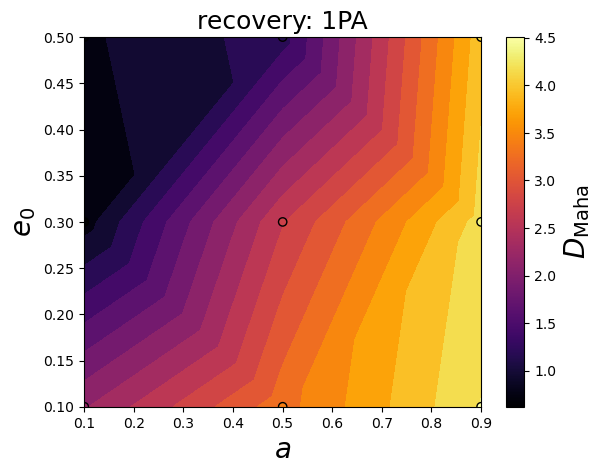

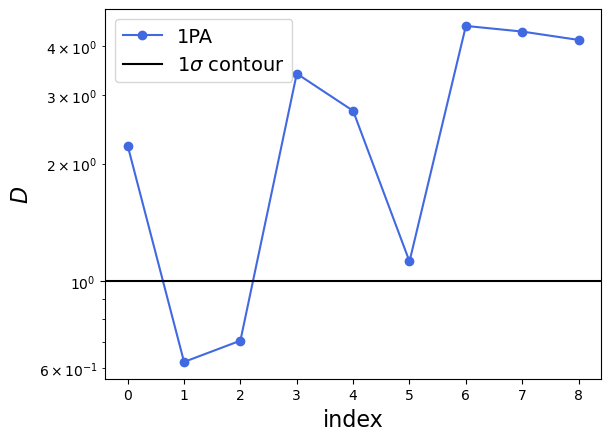

In [66]:
import matplotlib.colors as mcolors
import matplotlib.tri as tri

models_to_include = [0] #index of models from alternate_models_list to plot

alternate_models_list = np.array([
    '1PA',
    ])
alternate_models_list = alternate_models_list[models_to_include]

alternate_models_list_plotting = np.array([
    r'1PA',
    ])

alternate_models_list_plotting = alternate_models_list_plotting[models_to_include]

histtype = np.array([
    'bar',
    ])

histtype = histtype[models_to_include]

histcolor = np.array([
    'royalblue',
    ])

histcolor = histcolor[models_to_include]

alphas = np.array([
    1.0,
    ])

alphas = alphas[models_to_include]

edgecolor = np.array([
    None, 
    ])

edgecolor = edgecolor[models_to_include]

for j in range(len(alternate_models_list)):

    alternate_model = alternate_models_list[j]
    alt_plot = alternate_models_list_plotting[j]
    
    with h5py.File(f"{filename}/data.h5", "r") as f:
        param_grid = f["gridpoints"][:]  # Read the dataset into a NumPy array
        p_range = f["p0"][:] + p0_buffer #buffer

    filename_bias = os.path.join(filename,alternate_model)

    sigma_contours = []
    biased_a = []
    biased_e = []
    biases_1D = []
    for i in range(len(param_grid)):
        a = param_grid[i][0]
        e0 = param_grid[i][1]
        p0 = p_range[i]
        dist = dist_range[i]
        
        param_vals = [np.log(m1), np.log(m2), a, p0, e0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_r0]

        with h5py.File(f"{filename_bias}/Fisher_{i}.h5", "r") as f:
            Fisher_transformed = f["Fisher_transformed"][:]

        with h5py.File(f"{filename_bias}/biased_params_{i}.h5","r") as f:
            biased_params = f["biased_params"][:]
            biased_a.append(biased_params[2])
            biased_e.append(biased_params[4])
            
            sigma_contours.append(np.array(f["sigma_contours"]))

        covariance = np.linalg.inv(Fisher_transformed)

    sigma_contours = np.array(sigma_contours) 
    
    plt.plot(figsize=(7,5))
    
    x, y = param_grid[:, 0], param_grid[:, 1]

    # Create a triangulation
    triang = tri.Triangulation(x, y)

    plt.tricontourf(triang, sigma_contours, cmap='inferno',levels=15)
    
    if False:
        contour_line = plt.tricontour(triang, sigma_contours, levels=[1.0], colors='white', linewidths=2, linestyles='--')
        plt.clabel(contour_line, fmt={1.0: r"$D_{\rm Maha}=1.0$  "}, inline=True, fontsize=16, colors='white')

    plt.scatter(param_grid[:,0], param_grid[:,1], c = sigma_contours, cmap='inferno',edgecolor='black')

    scat_cb = plt.colorbar()
    scat_cb.set_label(r"$D_{\rm Maha}$",fontsize=20)

    biased_a = np.array(biased_a)
    biased_e = np.array(biased_e)

    plt.xlabel(r"$a$",fontsize=20)
    plt.ylabel(r"$e_0$",fontsize=20)    
    plt.title(f"recovery: {alt_plot}",fontsize=18)
    plt.savefig(f"{filename}/{alternate_model}_sigma_contours.png",bbox_inches='tight',dpi=300)
    plt.show()

for j in range(len(alternate_models_list)):

    with h5py.File(f"{filename}/data.h5", "r") as f:
        param_grid = f["gridpoints"][:]  # Read the dataset into a NumPy array
        p_range = f["p0"][:] + p0_buffer #buffer

    alternate_model = alternate_models_list[j]
    alt_plot = alternate_models_list_plotting[j]
    
    filename_bias = os.path.join(filename,alternate_model)

    sigma_contours = []

    for i in range(len(param_grid)):
        
        with h5py.File(f"{filename_bias}/biased_params_{i}.h5","r") as f:
            sigma_contours.append(np.array(f["sigma_contours"]))

    sigma_contours = np.array(sigma_contours)

    sigma_contours = np.array(sigma_contours)
    
    plt.plot(sigma_contours,marker='o',color=histcolor[j],label=alt_plot,alpha=alphas[j])
    
plt.yscale('log')
plt.axhline(1,color='black',linestyle='-',linewidth=1.5,label=r'$1\sigma$ contour')
plt.ylabel(r"$D$",fontsize=16)
plt.xlabel(r"index",fontsize=16)
plt.legend(fontsize=14)
plt.savefig(f"{filename}/histplot_sigmas.png",dpi=300,bbox_inches='tight')
plt.show()

CVbiases_Mtot_1000010.0/1PA
biased:  [13.81455552  2.30231066  0.09865306 10.88638708  0.10063899]
biased:  [13.81513159  2.30250531  0.09946277 10.89027992  0.30006726]
biased:  [13.81505131  2.30248022  0.09936949 10.85956735  0.50004321]
biased:  [13.81423609  2.30232819  0.49853965  9.99205023  0.10069671]
biased:  [13.81430724  2.30226562  0.49865713  9.97363972  0.3002325 ]
biased:  [13.81469531  2.30226676  0.49915113  9.89375936  0.50010026]
biased:  [13.81547718  2.30256006  0.89997059  9.05260662  0.10003205]
biased:  [13.81546263  2.30255251  0.89996056  9.01716361  0.30001484]
biased:  [13.81531805  2.30248584  0.89985852  8.90637514  0.5000281 ]
[[13.81455552  2.30231066  0.09865306 10.88638708  0.10063899]
 [13.81513159  2.30250531  0.09946277 10.89027992  0.30006726]
 [13.81505131  2.30248022  0.09936949 10.85956735  0.50004321]
 [13.81423609  2.30232819  0.49853965  9.99205023  0.10069671]
 [13.81430724  2.30226562  0.49865713  9.97363972  0.3002325 ]
 [13.81469531  2.3

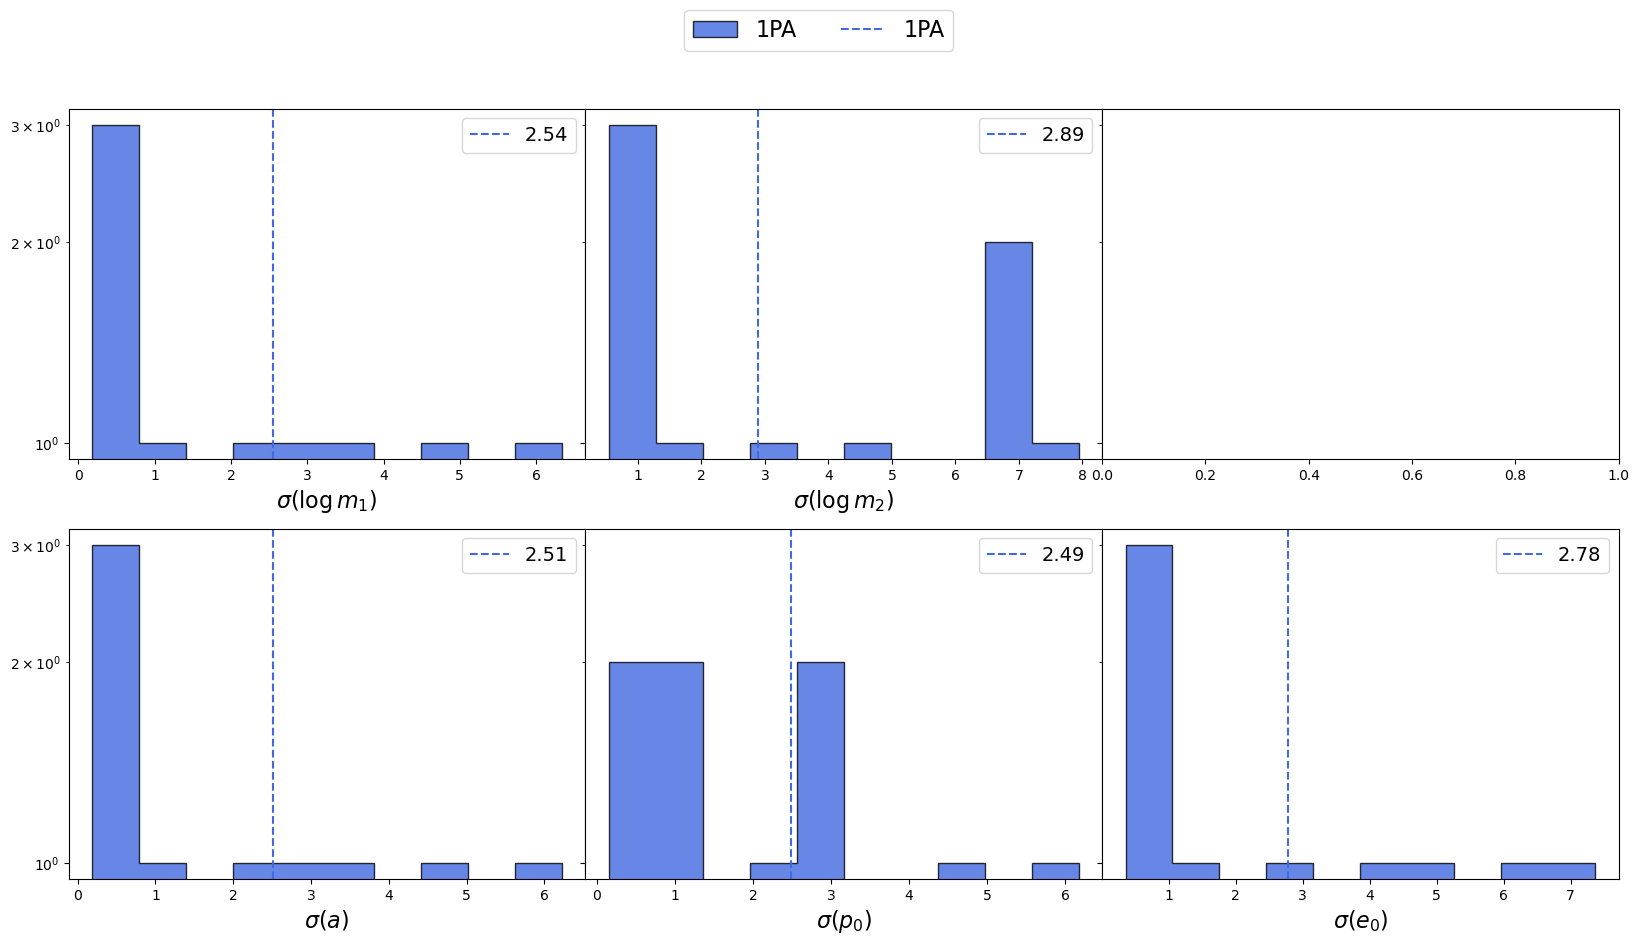

In [87]:
models_to_include = [0] #index of models from alternate_models_list to plot

alternate_models_list = np.array(['1PA'])
alternate_models_list = alternate_models_list[models_to_include]

alternate_models_list_plotting = np.array([r'1PA'])
alternate_models_list_plotting = alternate_models_list_plotting[models_to_include]

histtype = np.array(['stepfilled'])
histtype = histtype[models_to_include]

histcolor = np.array(['royalblue'])
histcolor = histcolor[models_to_include]

alphas = np.array([0.8,1.0,0.8,0.6])
alphas = alphas[models_to_include]

edgecolor = np.array(['black'])
edgecolor = edgecolor[models_to_include]

medianline_color = np.array(['royalblue'])
medianline_color = medianline_color[models_to_include]

medianline_style = np.array(['--'])
medianline_style = medianline_style[models_to_include]

param_names = ['m1','m2','a','chi2','p0','e0','dist','qS','phiS','qK','phiK','Phi_phi0','Phi_r0']

removed_params = ['chi2','dist','qS','phiS','qK','phiK','Phi_phi0','Phi_r0']

fig, axs = plt.subplots(2,(len(param_names)-len(removed_params))//2+1,figsize=(20,10),sharey=True, gridspec_kw={'wspace': 0})

logmass_sigmas = True #whether to calculate 1D sigma-biases with respect to the log mass parameterization (more stable) or not.

for j in range(len(alternate_models_list)):

    alternate_model = alternate_models_list[j]
    alt_plot = alternate_models_list_plotting[j]

    with h5py.File(f"{filename}/data.h5", "r") as f:
        param_grid = f["gridpoints"][:]  # Read the dataset into a NumPy array
        p_range = f["p0"][:] + p0_buffer #buffer
        dist_range = f["dists"][:]  # Read the dataset into a NumPy array

    a_range = np.linspace(0.1,0.9,N)
    e_range = np.linspace(0.1,0.5,N) #eccentricity above 0.5 is extremely expensive already...

    filename_bias = os.path.join(filename,alternate_model)
    print(filename_bias)
    
    sigma_contours = []
    #biased_a = []
    #biased_e = []
    biases_1D = []
    sigmas_1D = []
    truevals_1D = []
    
    for i in range(len(param_grid)):
        
        a = param_grid[i][0]
        e0 = param_grid[i][1]
        p0 = p_range[i]
        dist = dist_range[i]

        truevals_i = [np.log(m1), np.log(m2), a, chi2, p0, e0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_r0]
        param_names_plot = [r'$\log{m_1}$',r'$\log{m_2}$',r'$a$',r'$\chi_2$',r'$p_0$',r'$e_0$',r'$D_L$',r'$\theta_S$',r'$\phi_S$',r'$\theta_K$',r'$\phi_K$',r'$\Phi_{\phi_0}$',r'$\Phi_{r_0}$']

        with h5py.File(f"{filename_bias}/Fisher_{i}.h5", "r") as f:
            Fisher_transformed = f["Fisher_transformed"][:]

        rows_to_remove = []
        for _ in range(len(param_names)):
            if param_names[_] in removed_params:#'qK','phiK']:
                rows_to_remove.append(_)
    
        rows_to_remove = np.array(rows_to_remove)
        
        if len(rows_to_remove) > 0:
            Fisher_transformed = np.delete(np.delete(Fisher_transformed,rows_to_remove,axis=0),rows_to_remove,axis=1)
            param_names_plot = np.delete(param_names_plot, rows_to_remove, axis=0)
            truevals_i = np.delete(truevals_i, rows_to_remove, axis=0)

        truevals_1D.append(truevals_i)
        
        covariance = np.linalg.inv(Fisher_transformed)
        
        sigmas_params = np.sqrt(np.diag(covariance))

        with h5py.File(f"{filename_bias}/biased_params_{i}.h5","r") as f:
            biased_params = f["biased_params"][:]

        print('biased: ', biased_params)

        biases_1D.append(biased_params)
        sigmas_1D.append(sigmas_params)  

    biases_1D = np.array(biases_1D)
    sigmas_1D = np.array(sigmas_1D)
    truevals_1D = np.array(truevals_1D)

    sigmabias_1D = np.abs(biases_1D - truevals_1D)/sigmas_1D

    print(biases_1D, truevals_1D)

    for i in range(len(param_names_plot)):
        if i < len(param_names_plot)//2:
            axs[0,i].hist(sigmabias_1D[:,i],histtype=histtype[j],color=histcolor[j],alpha=alphas[j],edgecolor=edgecolor[j])
            axs[0,i].set_xlabel(r"$\sigma($" + rf"{param_names_plot[i]})",fontsize=16)
            axs[0,i].set_yscale('log')
        else:
            axs[1,i-len(param_names_plot)//2].hist(sigmabias_1D[:,i],histtype=histtype[j],color=histcolor[j],alpha=alphas[j],edgecolor=edgecolor[j])
            axs[1,i-len(param_names_plot)//2].set_xlabel(r"$\sigma($" + rf"{param_names_plot[i]})",fontsize=16)
            axs[1,i-len(param_names_plot)//2].set_yscale('log')

        if i < len(param_names_plot)//2:
            axs[0,i].axvline(np.median(sigmabias_1D[:,i]),linestyle=medianline_style[j],color=medianline_color[j],label=round(np.median(sigmabias_1D[:,i]), 2))
            axs[0,i].legend(fontsize=14)
        else:
            axs[1,i-len(param_names_plot)//2].axvline(np.median(sigmabias_1D[:,i]),linestyle=medianline_style[j],color=medianline_color[j],label=round(np.median(sigmabias_1D[:,i]), 2))
            axs[1,i-len(param_names_plot)//2].legend(fontsize=14)

fig.legend(labels = np.vstack((alternate_models_list_plotting,alternate_models_list_plotting)).ravel('F'), loc="upper center", bbox_to_anchor=(0.5, 0.99), ncol=2,fontsize=16)
plt.savefig(f"{filename}/1D_bias_comparison.png",dpi=300,bbox_inches='tight',transparent=False)
plt.show()